In [1]:
import gpt as g
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from itertools import permutations

import scipy
import math
from scipy import special as sp
import time

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x300000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize])
    return np.mean(resmpld)

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
def autocorrelation2(samples, separation, max_separation, binsize):
    mean = np.mean(samples)
    ACF = []
    err = []
    t = -1
    nskip = int(0)
    #binsize = 50
    
    for i in range(int(max_separation / separation)):
        t += separation
        temp = []
        
        for i in range(np.size(samples)-t):
            temp.append((samples[i+t] - mean) * (samples[i] - mean))
        
        N2 = np.size(temp)
    
        jk = Jackknife( N2-nskip, binsize )
        jk.set( simple_mean, temp )
        jk.do_it()
        
        ACF.append(np.mean(temp))
        err.append(jk.err())
    
    x = np.arange(1, np.size(ACF))
    for i in x:
        ACF[i] /= ACF[0]
        err[i] /= ACF[0]
        
    err[0] = 0.
    ACF[0] = 1.
    
    
    return ACF, err

In [4]:
size = 8
grid = g.grid([size, size, size, size], g.double)
rng = g.random(str(time.time()))

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)

GPT :       1.271143 s : Initializing gpt.random(1753194381.268245,vectorized_ranlux24_389_64) took 0.000205994 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [5]:
action_gauge = g.qcd.gauge.action.wilson(7.0)

metro = g.algorithms.markov.metropolis(rng)
inv = g.algorithms.inverter
sympl = g.algorithms.integrator.symplectic

log = sympl.log()
pure_gauge = True


In [6]:
# thermalize lattice first
beta = g.default.get_float("--beta", 7.0)
seed = g.default.get("--seed", "hmc-pure-gauge")
ntherm = g.default.get_int("--ntherm", 10)
n = g.default.get_int("--n", 200)
nwrite = g.default.get_int("--nwrite", 10)
g.default.set_verbose("omf4")

# conjugate momenta
mom = g.group.cartesian(U)

# Log
g.message(f"Lattice = {grid.fdimensions}")
g.message("Actions:")
# action for conj. momenta
a0 = g.qcd.scalar.action.mass_term()
g.message(f" - {a0.__name__}")

# wilson action 
a1 = g.qcd.gauge.action.wilson(beta)
g.message(f" - {a1.__name__}")
    
    
def hamiltonian():
    return a0(mom) + a1(U) 

# molecular dynamics
sympl = g.algorithms.integrator.symplectic
    
iphmc = sympl.update_p(mom, lambda: a1.gradient(U, U))
iqhmc = sympl.update_q(U, lambda: a0.gradient(mom, mom))

# integrator
mdint_hmc = sympl.leap_frog(50, iphmc, iqhmc)
#g.message(f"Integration scheme:\n{mdint}")
    
# metropolis
metro = g.algorithms.markov.metropolis(rng)
    
# MD units
tau = 1.0
g.message(f"tau = {tau} MD units")

def hmc(tau, mom):
    rng.normal_element(mom)
    accrej = metro(U)
    h0 = hamiltonian()
    mdint_hmc(tau)
    h1 = hamiltonian()
    return [accrej(h1, h0), h1 - h0]


# thermalization
for i in range(1, 20):
    h = []
    timer = g.timer("hmc")
    for _ in range(ntherm // 10):
        timer("trajectory")
        h += [hmc(tau, mom)]
    h = np.array(h)
    timer()
    g.message(f"{i*10} % of thermalization completed")
    g.message(timer)
    g.message(
        f"Plaquette = {g.qcd.gauge.plaquette(U)}, Acceptance = {np.mean(h[:,0]):.2f}, |dH| = {np.mean(np.abs(h[:,1])):.4e}"
    )


start = time.time()

# production
history = []
plaq = []


wf_energyHMC = []
for i in range(50):
    history += [hmc(tau, mom)]
    P = g.qcd.gauge.plaquette(U)
    plaq.append(P)
    g.message(f"Trajectory {i}, P={P}")
    #if i % nwrite == 0:
    #    g.save(f"ckpoint_lat.{seed}.{i}", U, g.format.nersc())

    """
    if i % 5 == 0:
        t = 0.0
        eps = 0.05
        U_wf = g.copy(U)
        
        for i in range(160): # t = 8
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)

        E = g.qcd.gauge.energy_density(U_wf)
        wf_energyHMC.append(E)
    """


end = time.time()
print("time taken = ", end - start)

history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")



GPT :       1.705517 s : Lattice = [8, 8, 8, 8]
GPT :       1.707190 s : Actions:
GPT :       1.707887 s :  - mass_term(m^-1 = 1.0)
GPT :       1.708485 s :  - wilson(7.0)
GPT :       1.709831 s : tau = 1.0 MD units
GPT :       2.378043 s : 10 % of thermalization completed
GPT :       2.378360 s : hmc:
                       : trajectory           6.67e-01 s (= 100.00 %); time/s = 6.67e-01/6.67e-01/6.67e-01 (min/max/avg)
GPT :       2.378996 s : Plaquette = 0.2928928082812793, Acceptance = 1.00, |dH| = 1.2825e+01
GPT :       3.015387 s : 20 % of thermalization completed
GPT :       3.015709 s : hmc:
                       : trajectory           6.36e-01 s (= 100.00 %); time/s = 6.36e-01/6.36e-01/6.36e-01 (min/max/avg)
GPT :       3.016460 s : Plaquette = 0.4004302813468106, Acceptance = 1.00, |dH| = 6.8511e+00
GPT :       3.644187 s : 30 % of thermalization completed
GPT :       3.644490 s : hmc:
                       : trajectory           6.28e-01 s (= 100.00 %); time/s = 6.28e-01/6

In [7]:
W = g.copy(U)

In [8]:
                                        # domain to be updated. even = False => odd
def freeze_connecting_links(block_size, even_coords, odd_coords, even = True):
    domain_even = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even)
    domain_odd = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd)

    if even:
        active_coords = even_coords
        frozen_coords = odd_coords
        domain_parity = domain_even
    else:
        active_coords = odd_coords
        frozen_coords = even_coords
        domain_parity = domain_odd
    
    def find_links_to_freeze():
        vol = block_size ** grid.nd
        links = []

        border_domains = []
        boundary_points = np.array([[0,0,0,0]], dtype=np.int32)
        for i in range(domain_parity.number_of_local_blocks//2 ) :
            domain =  active_coords[ vol*i : vol*(i+1) ] # pick out the coords in adjacent domains
            if np.any(domain[0] == 0) or np.any(domain[-1] == size-1):
                border_domains.append( i )
                boundary_points = np.concatenate(( boundary_points, domain )) # all points in the boundary domains are added 

        x = [1, size-1] + [0 for i in range(grid.nd - 2)]
        perms = np.unique(list(permutations(x)), axis=0)
        
        
        # removing loop over all domains here
        #for j in border_domains:
        j = border_domains[-1]
        domain = active_coords[ vol*j : vol*(j+1) ]
        max_vals = domain[-1]
            
        for k in domain:
            if np.any(k == max_vals): # really only need forward ends
                for l in perms:
                    if (boundary_points == (k + np.asarray(l, dtype=np.int32) ) % size ).all(axis=1).any():
                        links.append( [k , np.where(np.asarray(l) == 1)[0][0]])
        
        j = border_domains[-1]
        domain = active_coords[ vol*j : vol*(j+1) ]

        domain_entries = []
        for i in range(len(links)):
            domain_entries.append( [np.where((domain == links[i][0]).all(axis=1))[0], links[-i][1]] )

        frozen_links = []
        
        for i in range(domain_parity.number_of_local_blocks//2 ) :
            domain =  active_coords[ vol*i : vol*(i+1) ]
            for l in domain_entries:
                frozen_links.append( [domain[l[0]], l[1]])
        
        return frozen_links
    
    def freeze_opposite_parity_blocks():
        return frozen_coords
        
    def link_masks():
        frozen_sites = freeze_opposite_parity_blocks()
        frozen_links = find_links_to_freeze()

        mask = g.qcd.gauge.unit(grid)   
        
        for i in frozen_sites:
            for mu in range(grid.nd):
                mask[mu][i] = 0.
    
        for j in frozen_links:
            mask[j[1]][j[0]] = 0.
        

        return mask

    return link_masks()

In [9]:
def coordinate_mask(block_size, even_coords, odd_coords, even = True):
    vol = block_size ** grid.nd
    
    if even:
        conjugate_site_locations = even_coords
    else:
        conjugate_site_locations = odd_coords

    blocks_per_line = size // block_size // 2 # this should still be good (but check here)
    skip = vol * blocks_per_line # need to be careful about the order in which blocks appear in the domain
    
    idx  = np.arange(conjugate_site_locations.shape[0]) 
    mask11 = ((idx // skip) % 2) == 1 # create mask to keep 4, skip 4, keep 4 etc

    coord_mask = conjugate_site_locations[mask11] # apply mask 

    mask = g.qcd.gauge.unit(grid) 
        
    for i in coord_mask:
        for mu in range(grid.nd):
            mask[mu][i] = 0.

    return mask
    
def momentum_mask(block_size, even_coords, odd_coords, even = True):
    vol = block_size ** grid.nd
    
    if even:
        conjugate_site_locations = even_coords
    else:
        conjugate_site_locations = odd_coords
    
    blocks_per_line = size // block_size // 2
    skip = vol * blocks_per_line
    
    idx  = np.arange(conjugate_site_locations.shape[0])
    mask11 = ((idx // skip) % 2) == 0
    
    mom_mask = conjugate_site_locations[mask11]
    
    mask = g.qcd.gauge.unit(grid)   
        
    for i in mom_mask:
        for mu in range(grid.nd):
            mask[mu][i] = 0.
        
    return mask


In [10]:
def MC_Ham(U):
    return action_gauge(U)



In [14]:

def gauge_force_coord_update(frozen_links, momenta_mask, block_size):
    # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain ; should be done in 2 of 3 directions, and these can al be the same
    for i in [2,3]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, block_size)

    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * momenta_mask[mu]) # also need mask to block the other active domain!!!
    
    #print(V)
    
    x = log(lambda: V , "gauge")()
    
    return x

def gauge_force_mom_update(frozen_links, coordinate_mask, block_size):

     # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain
    for i in [2,3]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, -block_size)
        
    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * coordinate_mask[mu])
    
    
    x = log(lambda: V , "gauge")()
    
    return x

block_size = 4

even_coords = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even).gcoor
odd_coords = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd).gcoor


# try swapping coords
for i in range(len(even_coords)):
    x = even_coords[i].copy()
    even_coords[i][1] = x[3]
    even_coords[i][3] = x[1]

    y = odd_coords[i].copy()
    odd_coords[i][1] = y[3]
    odd_coords[i][3] = y[1]

    even_coords[i][0] = x[2]
    even_coords[i][2] = x[0]
    
    odd_coords[i][0] = y[2]
    odd_coords[i][2] = y[0]


even = False
frozen224 = freeze_connecting_links(block_size, even_coords, odd_coords, even)
coord_mask4 = coordinate_mask(block_size, even_coords, odd_coords, even)
mom_mask4 = momentum_mask(block_size, even_coords, odd_coords, even)


iq_14 = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(frozen224, mom_mask4, block_size), "gauge_force_coord_update")
)

iq_24 = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(frozen224, coord_mask4, block_size), "gauge_force_mom_update")
)

# integrator
mdint__4 = sympl.leap_frog(40, iq_14, iq_24)


In [16]:
energies2 = [MC_Ham(U)]

for i in range(10):
    mdint__4(tau)
    mdint__4(-tau) # something is still wrong
    energies2.append(MC_Ham(U))
    
    print("traj = ", i , "ham = ", energies2[-1])

traj =  0 ham =  57177.08547011657
traj =  1 ham =  57177.0854701168
traj =  2 ham =  57177.08547011701
traj =  3 ham =  57177.08547011721
traj =  4 ham =  57177.08547011741
traj =  5 ham =  57177.08547011764


KeyboardInterrupt: 

In [11]:
def MC_run(mdint__, tau):
    V = g.copy(U)
    Ei = MC_Ham(U)
    tau1 = tau * (np.random.randint(0,2)*2 - 1) 
    mdint__2(tau)
    Ef = MC_Ham(U)
    if np.exp(- (Ef - Ei)) < np.random.uniform(0,1):
        for mu in range(4):
            U[mu] @= V[mu]
        print("REJECT", "DELTA S = ", Ef - Ei )
    
        return 0

    else:
        return 1

In [25]:
# For GPT its easiest for me to just generate MDint_(shift direction)_(block sizes)_(even / odd) # smth is wrong
# working for lat size 4 block size 2 untested for larger lat size
MD_steps = 50
combos = [[0,1], [0,2], [0,3], [1,2], [1,3], [2,3]]
#combos = [[0,2], [2,3]]
#sizes = [2,4]
sizes = [2,4]

parity = [True, False]

#combos = [[0,2]]
#sizes = [2,]
#parity = [True]

# ll = direction, ff = sizes, ppa = parity
template = """
def gauge_force_coord_update_{ff}_{ll}_{ppa}(frozen_links, momenta_mask, block_size):
    # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain ; should be done in 2 of 3 directions, and these can al be the same
    for i in combos[{ll}]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, block_size)

    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * momenta_mask[mu]) # also need mask to block the other active domain!!!
    
    #print(V)
    
    x = log(lambda: V , "gauge")()
    
    return x

def gauge_force_mom_update_{ff}_{ll}_{ppa}(frozen_links, coordinate_mask, block_size):

     # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain
    for i in combos[{ll}]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, -block_size)
        
    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * coordinate_mask[mu])
    
    
    x = log(lambda: V , "gauge")()
    
    return x

block_size_{ff}_{ll}_{ppa} = sizes[{ff}]

even_coords_{ff}_{ll}_{ppa} = g.domain.even_odd_blocks(grid, [block_size_{ff}_{ll}_{ppa} for i in range(grid.nd)], g.even).gcoor
odd_coords_{ff}_{ll}_{ppa} = g.domain.even_odd_blocks(grid, [block_size_{ff}_{ll}_{ppa} for i in range(grid.nd)], g.odd).gcoor

# need to sort this out because the default is [0,1], so I'll need to swap zero only if the first digit changes

# need to do for second coord regardless
for i in range(len(even_coords_{ff}_{ll}_{ppa})):
    x = even_coords_{ff}_{ll}_{ppa}[i].copy()
    even_coords_{ff}_{ll}_{ppa}[i][1] = x[combos[{ll}][1]]
    even_coords_{ff}_{ll}_{ppa}[i][combos[{ll}][1]] = x[1]

    y = odd_coords_{ff}_{ll}_{ppa}[i].copy()
    odd_coords_{ff}_{ll}_{ppa}[i][1] = x[combos[{ll}][1]]
    odd_coords_{ff}_{ll}_{ppa}[i][combos[{ll}][1]] = x[1]

    if combos[{ll}][0] != 0:
        x = even_coords_{ff}_{ll}_{ppa}[i].copy()
        even_coords_{ff}_{ll}_{ppa}[i][0] = x[combos[{ll}][0]]
        even_coords_{ff}_{ll}_{ppa}[i][combos[{ll}][0]] = x[0]
    
        y = odd_coords_{ff}_{ll}_{ppa}[i].copy()
        odd_coords_{ff}_{ll}_{ppa}[i][0] = y[combos[{ll}][0]]
        odd_coords_{ff}_{ll}_{ppa}[i][combos[{ll}][0]] = y[0]


even_{ff}_{ll}_{ppa} = parity[{ppa}]

frozen_{ff}_{ll}_{ppa} = freeze_connecting_links(block_size_{ff}_{ll}_{ppa}, even_coords_{ff}_{ll}_{ppa}, odd_coords_{ff}_{ll}_{ppa}, even_{ff}_{ll}_{ppa})
coord_mask_{ff}_{ll}_{ppa} = coordinate_mask(block_size_{ff}_{ll}_{ppa}, even_coords_{ff}_{ll}_{ppa}, odd_coords_{ff}_{ll}_{ppa}, even_{ff}_{ll}_{ppa})
mom_mask_{ff}_{ll}_{ppa} = momentum_mask(block_size_{ff}_{ll}_{ppa}, even_coords_{ff}_{ll}_{ppa}, odd_coords_{ff}_{ll}_{ppa}, even_{ff}_{ll}_{ppa})


iq_{ff}_{ll}_{ppa} = sympl.update_q(   
    U, log(lambda: gauge_force_coord_update_{ff}_{ll}_{ppa}(frozen_{ff}_{ll}_{ppa}, mom_mask_{ff}_{ll}_{ppa}, block_size_{ff}_{ll}_{ppa}), "gauge_force_coord_update_{ff}_{ll}_{ppa}")
)

ip_{ff}_{ll}_{ppa} = sympl.update_p(
    U, log(lambda: gauge_force_mom_update_{ff}_{ll}_{ppa}(frozen_{ff}_{ll}_{ppa}, coord_mask_{ff}_{ll}_{ppa}, block_size_{ff}_{ll}_{ppa}), "gauge_force_mom_update_{ff}_{ll}_{ppa}")
)

# integrator
mdint_{ff}_{ll}_{ppa} = sympl.leap_frog(MD_steps, iq_{ff}_{ll}_{ppa}, ip_{ff}_{ll}_{ppa})
"""

# Build the code
code = []
for ff in range(len(sizes)):
    for ll in range(len(combos)):
        for ppa in range(len(parity)):
            code.append(template.format(ll = ll, ff = ff, ppa=ppa))

full_src = "\n".join(code)
print(full_src)
# Now load them into this module’s namespace
exec(full_src, globals())




def gauge_force_coord_update_0_0_0(frozen_links, momenta_mask, block_size):
    # calculate gradients
    V = action_gauge.gradient(U, U)

    # shift to other domain ; should be done in 2 of 3 directions, and these can al be the same
    for i in combos[0]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, block_size)

    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * momenta_mask[mu]) # also need mask to block the other active domain!!!

    #print(V)

    x = log(lambda: V , "gauge")()

    return x

def gauge_force_mom_update_0_0_0(frozen_links, coordinate_mask, block_size):

     # calculate gradients
    V = action_gauge.gradient(U, U)

    # shift to other domain
    for i in combos[0]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, -block_size)

    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * coordinate_mask[mu])


    x = log(lambda: V , "gauge")()

    return x

block_size_

Exception ignored in: <function lattice.__del__ at 0x109534c20>
Traceback (most recent call last):
  File "/Users/ell579/Documents/Physics/lattice/gpt/lib/gpt/core/lattice.py", line 105, in __del__
    del mem_book[self.v_obj[0]]
KeyError: 105553172467392


In [26]:
def MC_run(mdint__, tau):
    V = g.copy(U)
    Ei = MC_Ham(U)
    #tau1 = tau * (np.random.randint(0,2)*2 - 1) 
    mdint__(tau)
    Ef = MC_Ham(U)
    if np.exp(- (Ef - Ei)) < np.random.uniform(0,1):
        for mu in range(4):
            U[mu] @= V[mu]
        print("REJECT", "DELTA S = ", Ef - Ei )
    
        return 0

    else:
        return 1

In [27]:
# untested 

code1 = []

MC_run_template = """
def MC_run_set(tau):
    a = 0
"""

code1.append(MC_run_template)

MD_step_template = """
    a += MC_run(mdint_{ff}_{ll}_{ppa}, (tau))
"""
for ff in range(len(sizes)):
    for ll in range(len(combos)):
        for ppa in range(len(parity)):
            code1.append(MD_step_template.format(ll = ll, ff = ff, ppa=ppa))

ret_template = """
    return a
"""

code1.append(ret_template)

MD_src = "\n".join(code1)
print(MD_src)
exec(MD_src, globals())


def MC_run_set(tau):
    a = 0


    a += MC_run(mdint_0_0_0, (tau))


    a += MC_run(mdint_0_0_1, (tau))


    a += MC_run(mdint_0_1_0, (tau))


    a += MC_run(mdint_0_1_1, (tau))


    a += MC_run(mdint_0_2_0, (tau))


    a += MC_run(mdint_0_2_1, (tau))


    a += MC_run(mdint_0_3_0, (tau))


    a += MC_run(mdint_0_3_1, (tau))


    a += MC_run(mdint_0_4_0, (tau))


    a += MC_run(mdint_0_4_1, (tau))


    a += MC_run(mdint_0_5_0, (tau))


    a += MC_run(mdint_0_5_1, (tau))


    a += MC_run(mdint_1_0_0, (tau))


    a += MC_run(mdint_1_0_1, (tau))


    a += MC_run(mdint_1_1_0, (tau))


    a += MC_run(mdint_1_1_1, (tau))


    a += MC_run(mdint_1_2_0, (tau))


    a += MC_run(mdint_1_2_1, (tau))


    a += MC_run(mdint_1_3_0, (tau))


    a += MC_run(mdint_1_3_1, (tau))


    a += MC_run(mdint_1_4_0, (tau))


    a += MC_run(mdint_1_4_1, (tau))


    a += MC_run(mdint_1_5_0, (tau))


    a += MC_run(mdint_1_5_1, (tau))


    return a



In [28]:
dwfeMC2 = []
TPQ_mc = []
eps = 0.05

trajectories = 100

ergod = 1
history = 0

for i in range(trajectories):
    if i == 0:
        U_wf = g.copy(U)
        for l in range(160): # t = 4
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
                
        dwfeMC2.append( g.qcd.gauge.energy_density(U_wf))
        TPQ_mc.append( g.qcd.gauge.topological_charge(U_wf) )
    
    for k in range(ergod):
        hmc(tau, mom)
        print("HMC ", g.qcd.gauge.plaquette(U))
    
    history += MC_run_set(tau) # 12 hmc trajectories of force evaluation
    print("MC plaquette = ", g.qcd.gauge.plaquette(U))
    U_wf = g.copy(U)
    for l in range(160): # t = 4
        U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
    wff = g.qcd.gauge.energy_density(U_wf)
    Qf = g.qcd.gauge.topological_charge(U_wf)
    TPQ_mc.append( Qf )
        
    dwfeMC2.append(wff )
    
    print("Procedure ", i)
    print("WFE = ", wff)
    print("Q = ", Qf)

print(history / (trajectories * 4))
    
    

HMC  0.6704424730032357
REJECT DELTA S =  0.42815006853925297
MC plaquette =  0.670440272172069
Procedure  0
WFE =  (0.02100393502108122+2.760575014509216e-37j)
Q =  -0.8962951723205856
HMC  0.6713836041064855
REJECT DELTA S =  0.06317112228134647
REJECT DELTA S =  0.07870629816898145
MC plaquette =  0.6713805825895786
Procedure  1
WFE =  (0.02040294359863094-1.93290760538532e-37j)
Q =  -0.8912863934845919
HMC  0.6725798358309608
REJECT DELTA S =  0.18031749900546856
REJECT DELTA S =  0.8656467579639866
REJECT DELTA S =  0.49655020784121007
MC plaquette =  0.6725705758997989
Procedure  2
WFE =  (0.020072510958913322-1.1309541351856618e-37j)
Q =  -0.8920136849530967
HMC  0.6715688848684254
REJECT DELTA S =  0.349513345194282
REJECT DELTA S =  0.11066847458278062
REJECT DELTA S =  0.5948496331839124
MC plaquette =  0.6715661950248335
Procedure  3
WFE =  (0.019110722733012855+6.252849344657227e-38j)
Q =  -0.8680328345575032
HMC  0.6710703371770911
REJECT DELTA S =  0.3972679357684683
MC p

In [31]:
dwfeHMC2 = []
TPQ_hmc = []
eps = 0.05

trajectories = 100

ergod = 13
history = 0

for i in range(trajectories):
    if i == 0:
        U_wf = g.copy(U)
        for l in range(160): # t = 4
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
                
        dwfeHMC2.append( g.qcd.gauge.energy_density(U_wf))
        TPQ_hmc.append( g.qcd.gauge.topological_charge(U_wf) )
    
    for k in range(ergod):
        hmc(tau, mom)
        print("HMC ", g.qcd.gauge.plaquette(U))
    
    #history += MC_run_set(tau) # 12 hmc trajectories of force evaluation
    #print("MC plaquette = ", g.qcd.gauge.plaquette(U))
    
    U_wf = g.copy(U)
    for l in range(160): # t = 4
        U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
    wff = g.qcd.gauge.energy_density(U_wf)
    Qf = g.qcd.gauge.topological_charge(U_wf)
    TPQ_hmc.append( Qf )
        
    dwfeHMC2.append(wff )
    
    print("Procedure ", i)
    print("WFE = ", wff)
    print("Q = ", Qf)

print(history / (trajectories * 4))
    
    

HMC  0.6709225284153025
HMC  0.6716443581634154
HMC  0.672108438345192
HMC  0.6725792232762365
HMC  0.6732193223032055
HMC  0.6704829508310284
HMC  0.6732489876109424
HMC  0.6730660023456463
HMC  0.6712702807427532
HMC  0.6712702807427532
HMC  0.6726695588473485
HMC  0.6739412583799959
HMC  0.6749266639586146
Procedure  0
WFE =  (0.0006813405656333944+6.37108754596064e-40j)
Q =  -1.510105417596783e-05
HMC  0.6726342840141982
HMC  0.6704807519370148
HMC  0.6715275464209675
HMC  0.6715275464209675
HMC  0.6700294004209139
HMC  0.6697259664609053
HMC  0.6713152716827563
HMC  0.6725540044444508
HMC  0.6722471165316749
HMC  0.6736670886223285
HMC  0.6727033070513179
HMC  0.6727209528239034
HMC  0.6722665071364505
Procedure  1
WFE =  (0.0005067068883248901-2.7550648847397363e-40j)
Q =  4.264303208496849e-06
HMC  0.6724060756478427
HMC  0.673419921083216
HMC  0.6708016084807705
HMC  0.6709493139037837
HMC  0.6677373025640811
HMC  0.6681043547094361
HMC  0.6672369460886277
HMC  0.66646357831311

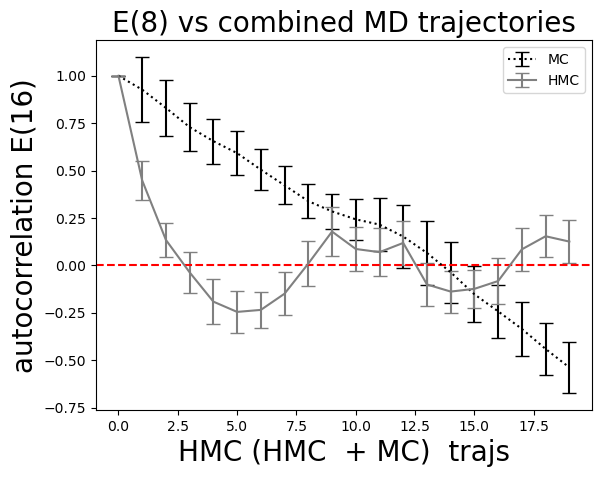

In [37]:
MC = autocorrelation2(dwfeMC2[20:], 1, 20, 1)
HMC = autocorrelation2(dwfeHMC2[20:], 1, 20, 1)


plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation E(16)", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
plt.errorbar(np.arange(len(MC[0])), MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0])), HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.legend()
#plt.savefig("2D_100_E16_AC.pdf")

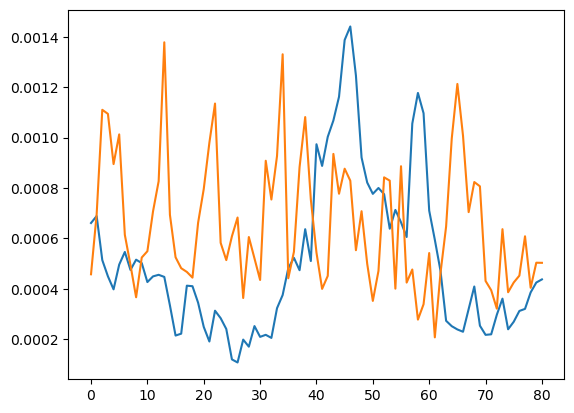

In [39]:
plt.plot(dwfeMC2[20:])
plt.plot(dwfeHMC2[20:])

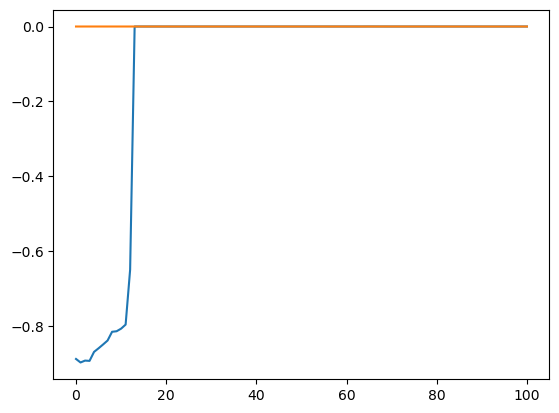

In [41]:
plt.plot(TPQ_mc)
plt.plot(TPQ_hmc)